# Assignment 5 - Generative Adversarial Networks (GAN)

## Grading rubric
Out of 100 points
- 50 points: Have the neural network train.
- 50 points: Have the neural network generate something better than the results found within the
- MLP GAN in the instructions. It should look something similar (or better) than this baseline:
![baseline](md_res/epoch8200cnn.png)

References:
- https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
- https://www.geeksforgeeks.org/deep-learning/generative-adversarial-networks-gans-in-pytorch/
- https://medium.com/codex/building-a-vanilla-gan-with-pytorch-ffdf26275b70
- https://github.com/eriklindernoren/Pytorch-GAN

# 0. Import Required Libraries

In [2]:
print("Starting imports of libraries...")

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

Starting imports of libraries...


# 2. Download Dataset

In [3]:
os.makedirs("data", exist_ok=True)

# 3. Build Generator

First, let's build our generator. As we can see, the generator takes a noise vector of size 100 as input. The generator's job is to create ("model"/"carve") something meaningful out of this noise vector — essentially creating new data.

Note on BatchNorm momentum: PyTorch's nn.BatchNorm1d(momentum=m) uses m as the weight given to the new batch statistics when updating the running mean and variance. A value of 0.2 means 20% of the update comes from the current batch.

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(100, 256 * 7 * 7)

        self.model = nn.Sequential(
            nn.BatchNorm2d(256),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128, momentum=0.1),
            nn.ReLU(True),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64, momentum=0.1),
            nn.ReLU(True),

            # Adding extra refinement pass to thicken strokes
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.1),
            nn.ReLU(True),

            # Final Output:  at 28x28
            nn.Conv2d(64, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 7, 7)
        return self.model(x)

# 4. Build Discriminator

Next, we have our discriminator. It takes in a flattened image (N, 1, 28, 28) and outputs a single value between 0 and 1 using sigmoid — 1 for real, 0 for fake. In PyTorch we simply create a separate optimizer for the discriminator.

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64, momentum=0.2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 7 -> 7
            nn.BatchNorm2d(128, momentum=0.2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)


device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator     = Generator().to(device)
discriminator = Discriminator().to(device)
print(discriminator)

# Adding Weights
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.2, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.2, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=6272, out_features=1, bias=True)
    (12): Sigmoid()
  )
)


Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.2, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.2, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=6272, out_features=1, bias=True)
    (12): Sigmoid()
  )
)

# 5. Load The MNIST dataset

1. Loading only the training images (throwing away labels, as this is unsupervised).
2. Rescaling the data from -1 to 1, to match the tanh activation found in our generator.
3. Flattening the images to (N, 1, 28, 28) vectors so they can be fed into the MLP discriminator.
4. Defining ground truth labels: 1 for valid (real) images, and 0 for fake, generated images.

In [6]:
# Load MNIST Dataset
train_data = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

X_train    = train_data.data.numpy().astype('float32')
X_train    = X_train / 127.5 - 1.          # rescale to [-1, 1]
X_train    = X_train.reshape(-1, 1, 28, 28)   # shape: (N, 1, 28, 28)
X_tensor   = torch.tensor(X_train).to(device)

BATCH_SIZE = 64
valid = torch.ones(BATCH_SIZE, 1).to(device) * 0.9   # real labels
fake  = torch.zeros(BATCH_SIZE, 1).to(device) + 0.1   # fake labels

# 6. Control Weights

1. gen_imgs.detach() when training the discriminator: this stops gradients from flowing back into the generator during the discriminator update step.
2. Separate optimizers: d_optimizer only holds the discriminator's parameters, and g_optimizer only holds the generator's parameters. When we call g_optimizer.step(), only generator weights update — the discriminator is untouched, even though gradients did flow through it.

In [7]:
criterion = nn.BCELoss()

d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
g_optimizer = optim.Adam(generator.parameters(),     lr=0.0002, betas=(0.5, 0.999))

# 7. Train Model

1. Randomly sample a batch of real images.
2. Create a latent noise vector (noise = torch.randn(BATCH_SIZE, 100)).
3. Get the generator to produce fake images from the noise vector.
4. Train the discriminator on real images (target: 1) and fake images (target: 0). Use .detach() on fake images so gradients do not flow into the generator.
5. Train the generator: pass new noise through the generator, then through the discriminator, and compute loss against valid (target: 1) — because the generator wants the discriminator to think its output is real.
6. Print out the losses of each.

In [8]:
g_losses = []
d_losses = []

for epoch in range(10000):

    # Sample real images
    idx  = np.random.randint(0, X_tensor.shape[0], BATCH_SIZE)
    imgs = X_tensor[idx]
    imgs = imgs.view(-1, 1, 28, 28)

    imgs = imgs + 0.02 * torch.randn_like(imgs)
    imgs = torch.clamp(imgs, -1, 1)

    # Train Discriminator
    noise    = torch.randn(BATCH_SIZE, 100).to(device)
    gen_imgs = generator(noise).detach()

    d_optimizer.zero_grad()
    d_loss_real = criterion(discriminator(imgs), valid)
    d_loss_fake = criterion(discriminator(gen_imgs), fake)
    d_loss      = (d_loss_real + d_loss_fake) / 2
    d_loss.backward()
    d_optimizer.step()

    # Train Generator
    noise    = torch.randn(BATCH_SIZE, 100).to(device)
    gen_imgs = generator(noise)

    g_optimizer.zero_grad()
    g_loss = criterion(discriminator(gen_imgs), valid)
    g_loss.backward()
    g_optimizer.step()

    # Logging
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    with torch.no_grad():
        real_pred = discriminator(imgs)
        fake_pred = discriminator(gen_imgs.detach())

    d_acc = ((real_pred > 0.5).float().mean().item() +
             (fake_pred < 0.5).float().mean().item()) / 2

    comb_str = "Epoch {:.5s}: {:.40s} | {} ".format(
        f"{epoch}{' ' * 100}",
        f"Discriminator - Loss: {round(d_loss.item(),4)}, Acc: {round(d_acc,4)} {' ' * 100}",
        f"Generator - Loss: {round(g_loss.item(),4)}")
    print(comb_str)

    # Save sample images
    if epoch % 200 == 0:
        r, c = 5, 5
        noise = torch.randn(r * c, 100).to(device)

        generator.eval()
        with torch.no_grad():
            gen_imgs = generator(noise).cpu().numpy()
        generator.train()

        gen_imgs = 0.5 * gen_imgs + 0.5
        gen_imgs = gen_imgs.reshape(-1, 28, 28)

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt], cmap="gray")
                axs[i, j].axis("off")
                cnt += 1

        os.makedirs("imgscnn", exist_ok=True)
        fig.savefig(f"imgscnn/{epoch}.png")
        plt.close()

Epoch 0    : Discriminator - Loss: 0.698, Acc: 0.5156 | Generator - Loss: 0.7354 
Epoch 1    : Discriminator - Loss: 0.7092, Acc: 0.609 | Generator - Loss: 0.7102 
Epoch 2    : Discriminator - Loss: 0.7057, Acc: 0.570 | Generator - Loss: 0.6712 
Epoch 3    : Discriminator - Loss: 0.6951, Acc: 0.570 | Generator - Loss: 0.7501 
Epoch 4    : Discriminator - Loss: 0.6997, Acc: 0.562 | Generator - Loss: 0.7577 
Epoch 5    : Discriminator - Loss: 0.6992, Acc: 0.562 | Generator - Loss: 0.7157 
Epoch 6    : Discriminator - Loss: 0.6552, Acc: 0.593 | Generator - Loss: 0.7683 
Epoch 7    : Discriminator - Loss: 0.6706, Acc: 0.679 | Generator - Loss: 0.803 
Epoch 8    : Discriminator - Loss: 0.6736, Acc: 0.617 | Generator - Loss: 0.7872 
Epoch 9    : Discriminator - Loss: 0.6615, Acc: 0.679 | Generator - Loss: 0.7662 
Epoch 10   : Discriminator - Loss: 0.6602, Acc: 0.695 | Generator - Loss: 0.7657 
Epoch 11   : Discriminator - Loss: 0.6436, Acc: 0.703 | Generator - Loss: 0.7994 
Epoch 12   : Disc

# Results

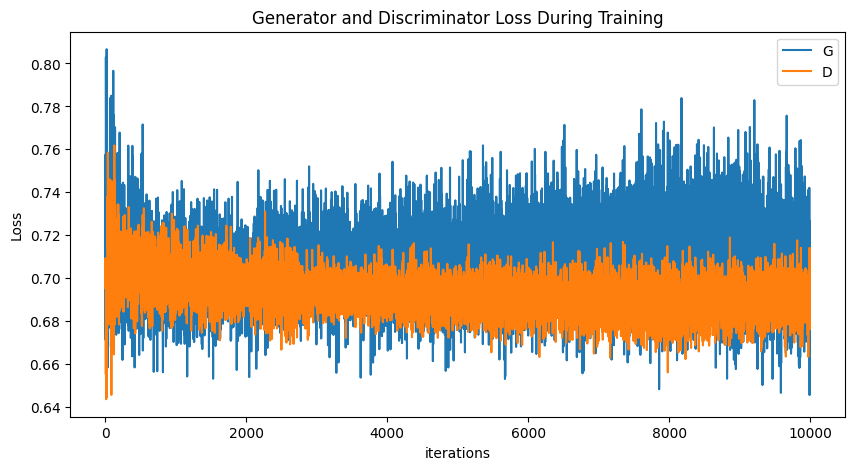

In [9]:
DIAG_DIR = "./diagrams"
os.makedirs(DIAG_DIR, exist_ok=True)

plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(g_losses, label="G")
plt.plot(d_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"{DIAG_DIR}/generator_and_discriminator_loss_training.png", dpi=300)
plt.show()

# Create a Grid

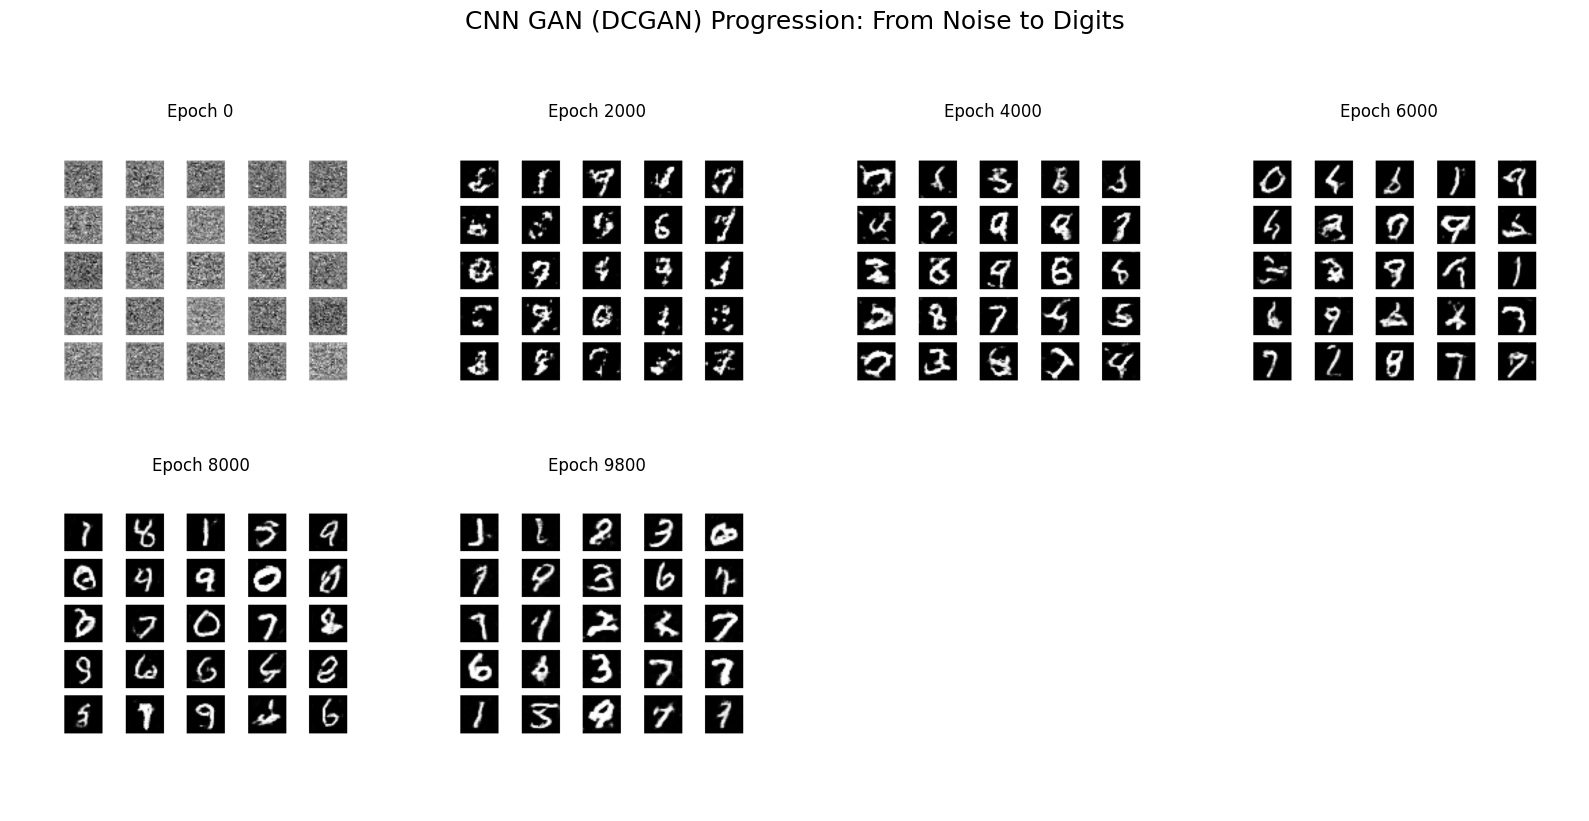

In [10]:
# Part 1: Progression Grid For CNN
MLP_DIR = "./imgsmlp"
CNN_DIR = "./imgscnn"

# Filter for .png files and sort numerically
files = sorted([
    int(f.replace(".png", ""))
    for f in os.listdir(CNN_DIR)
    if f.endswith(".png")
])

# epochs_to_show = [e for e in files if e % 2000 == 0 or e == max(files)]
epochs_to_show = sorted(list(set([0, 2000, 4000, 6000, 8000, max(files)])))

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()

for i, epoch in enumerate(epochs_to_show[:8]):
    img_path = os.path.join(CNN_DIR, f"{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axs[i].imshow(img)
        axs[i].set_title(f"Epoch {epoch}", fontsize=12)
    axs[i].axis("off")

# Hide any unused subplots
for j in range(len(epochs_to_show), len(axs)):
    axs[j].axis("off")

plt.suptitle("CNN GAN (DCGAN) Progression: From Noise to Digits", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(f"{DIAG_DIR}/cnn_gan_epoch_progression.png", dpi=150)
plt.show()

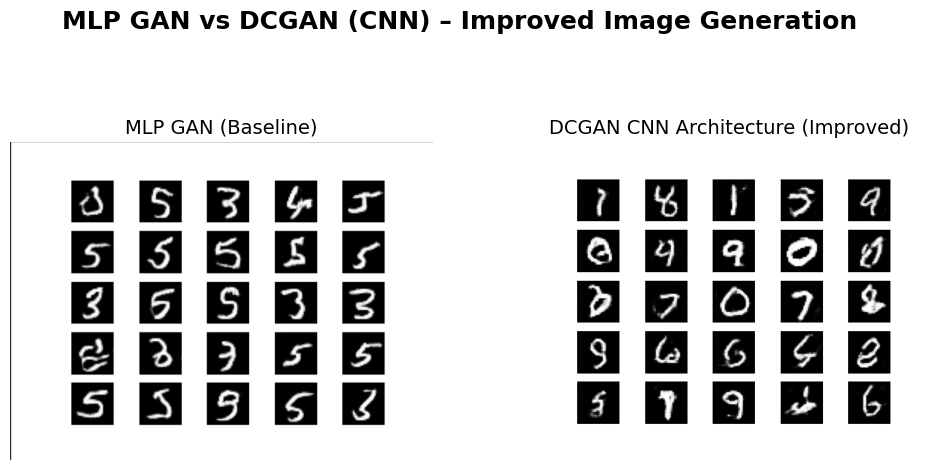

In [11]:
# Part 2: MLP vs CNN Comparison Grid
BEST_EPOCH = 8000

mlp_final_path = "imgsmlp/MLP_GAN_Baseline.png"
cnn_final_path = f"./imgscnn/{BEST_EPOCH}.png"


if os.path.exists(mlp_final_path) and os.path.exists(cnn_final_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(mpimg.imread(mlp_final_path))
    ax1.set_title("MLP GAN (Baseline)", fontsize=14)
    ax1.axis("off")

    ax2.imshow(mpimg.imread(cnn_final_path))
    ax2.set_title("DCGAN CNN Architecture (Improved)", fontsize=14)
    ax2.axis("off")

    plt.suptitle("MLP GAN vs DCGAN (CNN) – Improved Image Generation", fontsize=18, fontweight='bold')
    plt.savefig(f"{DIAG_DIR}/mlp_vs_cnn_comparison.png", dpi=150)
    plt.show()
else:
    print("Could not find final images for comparison. Check your file paths!")

In [12]:
# import shutil
# import os
#
# folder = "imgscnn"
#
# # Delete if exists
# if os.path.exists(folder):
#     shutil.rmtree(folder)
#
# # Recreate clean folder
# os.makedirs(folder, exist_ok=True)
#
# print("Reset folder: imgscnn")